In [7]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import hvplot.xarray
from scipy.ndimage import gaussian_filter
from scipy.spatial import cKDTree

# Physics preprocess

## Read CMEMS and grid

In [8]:
cmems = xr.open_dataset(os.path.join("P1D-m_1745438014042.nc")).isel(depth=slice(0,21))

In [9]:
cmems

<xarray.Dataset> Size: 255MB
Dimensions:      (time: 366, depth: 21, latitude: 25, longitude: 81)
Coordinates:
  * time         (time) datetime64[ns] 3kB 1991-01-01 1991-01-02 ... 1992-01-01
  * depth        (depth) float32 84B -0.0 2.0 4.0 6.0 ... 175.0 200.0 250.0
  * latitude     (latitude) float32 100B 64.0 64.12 64.25 ... 66.75 66.88 67.0
  * longitude    (longitude) float32 324B -28.0 -27.88 -27.75 ... -18.12 -18.0
Data variables:
    so           (time, depth, latitude, longitude) float32 62MB ...
    thetao       (time, depth, latitude, longitude) float32 62MB ...
    vxo          (time, depth, latitude, longitude) float32 62MB ...
    model_depth  (latitude, longitude) float32 8kB ...
    vyo          (time, depth, latitude, longitude) float32 62MB ...
    zos          (time, latitude, longitude) float32 3MB ...
    sithick      (time, latitude, longitude) float32 3MB ...
Attributes:
    Conventions:       CF-1.11
    title:             Arctic Ocean Physics Reanalysis
    institution:       NERSC, Jahnebakken 3, N-5007 Bergen, Norway
    source:            NERSC-HYCOM model fields
    history:           20220829:Created by program hyc2proj, version V0.3
    references:        http://topaz.nersc.no
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  ARCTIC_MULTIYEAR_PHY_002_003
    subset:datasetId:  cmems_mod_arc_phy_my_topaz4_P1D-m_202211
    subset:date:       2025-04-23T19:53:34.043Z

In [4]:
#45:end,1:640

In [10]:
topo = xr.open_dataset('Isafjardardjup_topo.nc').isel(x=slice(44,None,2), y=slice(0,640,2))

In [11]:
lon_grid = topo.lonv.values
lat_grid = topo.latv.values

## Subset CMEMS for nearest available longitude

In [14]:
lon_tgt = -25 # nearest available
lat_tgt = lat_grid

In [15]:
cmems_subset = cmems.sel(longitude = lon_tgt, latitude = lat_tgt, method='nearest')

In [18]:
cmems_subset.so.isel(time=0, depth=12).hvplot()

:Curve   [latitude]   (Salinity)

In [19]:
cmems.thetao.isel(time=0, depth=0).hvplot(cmap='coolwarm')

:Image   [longitude,latitude]   (Sea Temperature)

In [22]:
cmems.model_depth.hvplot(cmap='ocean')

:Image   [longitude,latitude]   (Sea floor depth below sea level)

## Interpolate on z-centers

>! **NB:** Should be updated to positive z-coordinate in latest version of Oceananigans

In [23]:
z_faces = [
      -190.0,
    -170.0,
      -150.0,
    -140.0,
    -130.0,
    -120.0,
    -110.0,
      -100.0,
    -90.0,
    -80.0,
    -70.0,
      -60.0,
      -50.0,
    -40.0,
      -30.0,
    -25.0,
      -20.0,
    -18.0,
    -16.0,
    -14.0,
    -12.0,
      -10.0,
    -8.0,
    -6.0,
    -5.0,
    -4.0,
    -3.0,
       -2.0,
    -1.0,
        0.0
]

In [24]:
z_centers = [(z_faces[i] + z_faces[i+1]) / 2 for i in range(len(z_faces) - 1)]

In [25]:
z_centers

[-180.0,
 -160.0,
 -145.0,
 -135.0,
 -125.0,
 -115.0,
 -105.0,
 -95.0,
 -85.0,
 -75.0,
 -65.0,
 -55.0,
 -45.0,
 -35.0,
 -27.5,
 -22.5,
 -19.0,
 -17.0,
 -15.0,
 -13.0,
 -11.0,
 -9.0,
 -7.0,
 -5.5,
 -4.5,
 -3.5,
 -2.5,
 -1.5,
 -0.5]

In [28]:
cmems_subset["depth"] = -cmems_subset.depth

In [29]:
cmems_subset["depth"]

<xarray.DataArray 'depth' (depth: 21)> Size: 84B
array([   0.,   -2.,   -4.,   -6.,  -10.,  -15.,  -20.,  -25.,  -30.,  -40.,
        -50.,  -60.,  -70.,  -80.,  -90., -100., -125., -150., -175., -200.,
       -250.], dtype=float32)
Coordinates:
  * depth      (depth) float32 84B 0.0 -2.0 -4.0 -6.0 ... -175.0 -200.0 -250.0
    longitude  float32 4B -25.0
Attributes:
    standard_name:  depth
    long_name:      Depth
    units:          m
    unit_long:      Meters
    axis:           Z
    positive:       down

### from cmems_subset to ds

In [30]:
ds = cmems_subset.rename({"longitude": "Nx", "latitude": "Ny", "depth": "Nz", "thetao": "T", "so": "S", "vxo": "u", "vyo": "v"})

In [31]:
ds = ds.isel(time=slice(None,-1))

The following will take a minute to run

In [32]:
ds = ds.interp(Nz=z_centers, method="linear")

### Fill NaN from 70 to 200 m

In [33]:
ds = ds.bfill(dim='Nz')

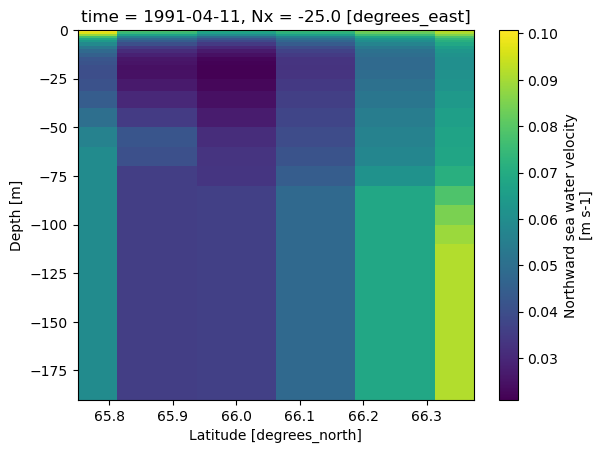

In [34]:
ds['v'].isel(time=100).plot()

In [35]:
ds

<xarray.Dataset> Size: 109MB
Dimensions:      (time: 365, Ny: 320, Nz: 29)
Coordinates:
  * time         (time) datetime64[ns] 3kB 1991-01-01 1991-01-02 ... 1991-12-31
  * Ny           (Ny) float32 1kB 65.75 65.75 65.75 65.75 ... 66.38 66.38 66.38
    Nx           float32 4B -25.0
  * Nz           (Nz) float64 232B -180.0 -160.0 -145.0 ... -2.5 -1.5 -0.5
Data variables:
    S            (time, Nz, Ny) float64 27MB 35.03 35.03 35.03 ... 34.96 34.96
    T            (time, Nz, Ny) float64 27MB 4.7 4.7 4.7 ... 4.599 4.599 4.599
    u            (time, Nz, Ny) float64 27MB 0.02076 0.02076 ... 0.05245 0.05245
    model_depth  (Ny) float32 1kB 78.02 78.02 78.02 78.02 ... 147.0 147.0 147.0
    v            (time, Nz, Ny) float64 27MB 0.03575 0.03575 ... -0.0003615
    zos          (time, Ny) float32 467kB -0.4435 -0.4435 ... -0.4738 -0.4738
    sithick      (time, Ny) float32 467kB 0.0 0.0 0.0 ... 1.328e-06 1.328e-06
Attributes:
    Conventions:       CF-1.11
    title:             Arctic Ocean Physics Reanalysis
    institution:       NERSC, Jahnebakken 3, N-5007 Bergen, Norway
    source:            NERSC-HYCOM model fields
    history:           20220829:Created by program hyc2proj, version V0.3
    references:        http://topaz.nersc.no
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  ARCTIC_MULTIYEAR_PHY_002_003
    subset:datasetId:  cmems_mod_arc_phy_my_topaz4_P1D-m_202211
    subset:date:       2025-04-23T19:53:34.043Z

# Boundaries

## zeros containers for grid

In [36]:
# grid params
nx = 299
ny = 320
nz = len(z_centers)

nt = 365 # 1 year

In [38]:
np_temp = np.zeros((nt, nz, ny, nx), dtype=np.float32)
np_salt = np.zeros((nt, nz, ny, nx), dtype=np.float32)
np_u = np.zeros((nt, nz, ny, nx+1), dtype=np.float32)
np_v = np.zeros((nt, nz, ny+1, nx), dtype=np.float32)

## get arrays from ds and smooth

In [39]:
tcmems = gaussian_filter(ds['T'].values, sigma=(0.2,0.1,15))
scmems = gaussian_filter(ds['S'].values, sigma=(0.2,0.1,15))
ucmems = gaussian_filter(ds['u'].values, sigma=(0.2,0.1,15))
vcmems = gaussian_filter(ds['v'].values, sigma=(0.2,0.1,15))

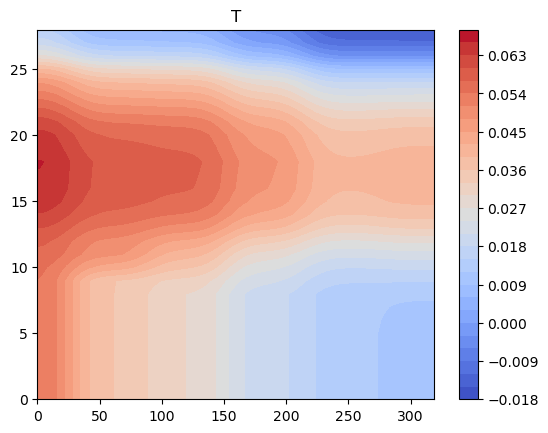

In [40]:
plt.contourf(vcmems[50,:,:], cmap='coolwarm', levels=30)
plt.title('T')
plt.colorbar()

In [41]:
vcmems.shape

(365, 29, 320)

In [42]:
vcmems2 = np.concat((vcmems, vcmems[:,:,-1, np.newaxis]), axis=2)

In [43]:
np_temp[:,:,:,0] = tcmems
np_temp[:,:,-1,:] = np.repeat(tcmems[:,:,-1, np.newaxis], nx, axis=2)

np_salt[:,:,:,0] = scmems
np_salt[:,:,-1,:] = np.repeat(scmems[:,:,-1, np.newaxis], nx, axis=2)

np_u[:,:,:,0] = ucmems
np_u[:,:,-1,:] = np.repeat(ucmems[:,:,-1, np.newaxis], nx+1, axis=2)

np_v[:,:,:,0] = vcmems2
np_v[:,:,-1,:] = np.repeat(vcmems2[:,:,-1, np.newaxis], nx, axis=2)

# Rivers

In [44]:
grid_depth = topo.depth.values

## River positions and discharge data

River coordinates (ISN93 and WGS84):
- V38 Þverá: ISN93 (347.710, 605.120), WGS84 (65.9067°N, 22.3433°W)
- V198 Hvalá: ISN93 (376.370, 621.715), WGS84 (66.0677°N, 21.7307°W)  
- V449 Dynjandisá: ISN93 (366.940, 588.620), WGS84 (65.7372°N, 23.2118°W)
- V204 Vatnsdalsá: ISN93 (309.380, 571.480), WGS84 (65.5852°N, 23.1344°W)

These will be interpolated to the nearest valid grid points where depth is not NaN.

In [48]:
# River coordinates
river_names = ['V38_Thvera', 'V198_Hvala', 'V449_Dynjandisa', 'V204_Vatnadalsa']
river_lats = [65.9067, 66.0677, 65.7372, 65.5852]  # degrees N
river_lons = [-22.3433, -21.7307, -23.2118, -23.1344]  # degrees W

In [49]:
# Create mask of valid (non-NaN) grid points
valid_mask = ~np.isnan(grid_depth)
valid_indices = np.argwhere(valid_mask)

lon_gridm, lat_gridm = np.meshgrid(lon_grid, lat_grid)

In [50]:
# Get lat/lon coordinates of valid grid points
valid_lons = lon_gridm[valid_mask]
valid_lats = lat_gridm[valid_mask]

# Build KD-tree for efficient nearest neighbor search
tree = cKDTree(np.column_stack([valid_lats, valid_lons]))

# Find nearest valid grid point for each river
xrivers = []
yrivers = []

for i, (name, rlat, rlon) in enumerate(zip(river_names, river_lats, river_lons)):
    # Find nearest valid point
    dist, idx = tree.query([rlat, rlon])
    y_idx, x_idx = valid_indices[idx]
    xrivers.append(x_idx)
    yrivers.append(y_idx)
    print(f"{name}: Grid indices ({x_idx}, {y_idx}), Distance: {dist:.4f} deg, Depth: {grid_depth[y_idx, x_idx]:.1f}m")

V38_Thvera: Grid indices (287, 73), Distance: 0.0010 deg, Depth: 2.0m
V198_Hvala: Grid indices (288, 76), Distance: 0.6289 deg, Depth: 2.0m
V449_Dynjandisa: Grid indices (102, 103), Distance: 0.2621 deg, Depth: 2.0m
V204_Vatnadalsa: Grid indices (127, 74), Distance: 0.3561 deg, Depth: 2.0m


Text(0, 0.5, 'y index')

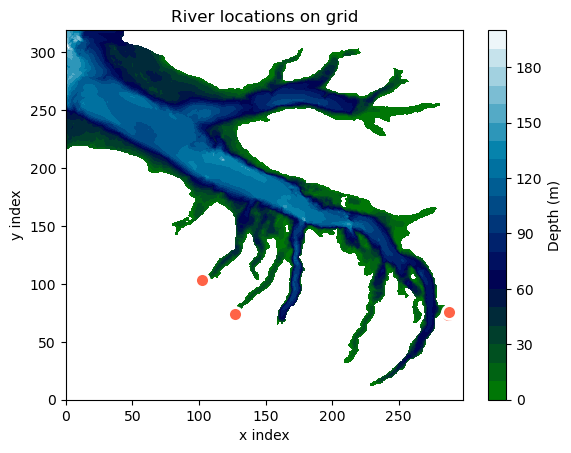

In [51]:
# Visualize river locations on bathymetry
cf = plt.contourf(grid_depth, cmap='ocean', levels=20)
for i, (name, x, y) in enumerate(zip(river_names, xrivers, yrivers)):
    plt.scatter(x, y, c='tomato', s=100, edgecolors='white', linewidths=2, label=name if i == 0 else "")
plt.colorbar(cf, label='Depth (m)')
plt.title('River locations on grid')
plt.xlabel('x index')
plt.ylabel('y index')

## Read river discharge data from Excel

In [52]:
# Map river sheet names in Excel file
river_sheet_map = {
    'V38_Thvera': 'V38',
    'V198_Hvala': 'V198',
    'V449_Dynjandisa': 'V449',
    'V204_Vatnadalsa': 'V204'
}

In [53]:
excel_name = 'rivers_Q.xlsx'

In [54]:
# Read discharge data for each river
river_discharge = {}

for river_name, sheet_name in river_sheet_map.items():
    df = pd.read_excel(excel_name, sheet_name=sheet_name)
    
    # Extract discharge column (Q24M in m³/s)
    # Handle different column formats
    if 'Q24M (m3/s)' in df.columns:
        Q = df['Q24M (m3/s)'].values
    else:
        # Try alternative column name
        Q = df.iloc[:, 1].values  # Second column is usually discharge
    
    # Convert date to datetime if needed
    if 'date' in df.columns:
        dates = pd.to_datetime(df['date'])
    else:
        dates = pd.to_datetime(df.iloc[:, 0])
    
    river_discharge[river_name] = {
        'dates': dates,
        'Q_m3s': Q
    }
    
    print(f"{river_name}: {len(Q)} records, mean Q = {np.nanmean(Q):.2f} m³/s")

# Check date range
print(f"\nDate range: {dates.min()} to {dates.max()}")

V38_Thvera: 3653 records, mean Q = 2.31 m³/s
V198_Hvala: 3653 records, mean Q = 15.25 m³/s
V449_Dynjandisa: 3653 records, mean Q = 3.12 m³/s
V204_Vatnadalsa: 3653 records, mean Q = 7.38 m³/s

Date range: 2014-10-01 00:00:00 to 2024-09-30 00:00:00


## Calculate mean annual discharge for each river

In [55]:
# Calculate mean annual discharge for each river (m³/s)
river_Q_mean = {}

for river_name in river_names:
    Q_values = river_discharge[river_name]['Q_m3s']
    # Remove NaN values for mean calculation
    Q_clean = Q_values[~np.isnan(Q_values)]
    river_Q_mean[river_name] = np.mean(Q_clean)
    print(f"{river_name}: Mean Q = {river_Q_mean[river_name]:.2f} m³/s")

# Store discharge values in array matching river order
Q_rivers = np.array([river_Q_mean[name] for name in river_names])
print(f"\nTotal discharge: {Q_rivers.sum():.2f} m³/s")

V38_Thvera: Mean Q = 2.31 m³/s
V198_Hvala: Mean Q = 15.25 m³/s
V449_Dynjandisa: Mean Q = 3.12 m³/s
V204_Vatnadalsa: Mean Q = 7.38 m³/s

Total discharge: 28.05 m³/s


In [56]:
# Create summary table
summary_data = []
for i, name in enumerate(river_names):
    summary_data.append({
        'River': name,
        'Lat (°N)': river_lats[i],
        'Lon (°W)': river_lons[i],
        'Grid X': xrivers[i],
        'Grid Y': yrivers[i],
        'Mean Q (m³/s)': f"{Q_rivers[i]:.2f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\n=== River Summary ===")
print(summary_df.to_string(index=False))


=== River Summary ===
          River  Lat (°N)  Lon (°W)  Grid X  Grid Y Mean Q (m³/s)
     V38_Thvera   65.9067  -22.3433     287      73          2.31
     V198_Hvala   66.0677  -21.7307     288      76         15.25
V449_Dynjandisa   65.7372  -23.2118     102     103          3.12
V204_Vatnadalsa   65.5852  -23.1344     127      74          7.38


## Calculate grid cell volumes

Cell volume depends on:
- Horizontal area (from lat/lon grid spacing)
- Vertical thickness (from z_faces)

In [62]:
# Calculate horizontal grid cell area
# Approximate using spherical earth with R = 6371 km
R_earth = 6371e3  # meters

# Grid spacing in degrees
dlat = (lat_grid.max() - lat_grid.min()) / ny
dlon = (lon_grid.max() - lon_grid.min()) / nx

print(f"Grid spacing: dlat = {dlat:.4f}°, dlon = {dlon:.4f}°")

# Convert to meters (approximate for small areas)
# dy ≈ R * dlat (in radians)
# dx ≈ R * dlon * cos(lat) (in radians)
dy = R_earth * np.radians(dlat)

# Create array of cell areas (varies with latitude)
cell_area = np.zeros((ny, nx))
for j in range(ny):
    lat_cell = lat_grid[j, 0] if lat_grid.ndim == 2 else lat_grid[j]
    dx = R_earth * np.radians(dlon) * np.cos(np.radians(lat_cell))
    cell_area[j, :] = dx * dy

print(f"Cell area range: {cell_area.min():.2f} - {cell_area.max():.2f} m²")

# Calculate vertical layer thicknesses
dz = np.abs(np.diff(z_faces))  # thickness of each layer
print(f"\nVertical layers: {len(dz)} layers")
print(f"Layer thickness range: {dz.min():.1f} - {dz.max():.1f} m")

Grid spacing: dlat = 0.0020°, dlon = 0.0040°
Cell area range: 39347.69 - 40348.00 m²

Vertical layers: 29 layers
Layer thickness range: 1.0 - 20.0 m


In [63]:
# Calculate cell volumes for river locations
# Volume = horizontal_area * vertical_thickness

river_cell_volumes = []

for i, (name, x, y) in enumerate(zip(river_names, xrivers, yrivers)):
    # Get area of this cell
    area = cell_area[y, x]
    
    # Calculate volume for each vertical layer
    # Total water column volume
    volumes = area * dz  # array of volumes for each layer
    total_volume = volumes.sum()
    
    river_cell_volumes.append(volumes)
    
    print(f"{name}:")
    print(f"  Grid cell: ({x}, {y})")
    print(f"  Horizontal area: {area:.3f} m²")
    print(f"  Total water column volume: {total_volume:.3f} m³")
    print(f"  Mean discharge: {Q_rivers[i]:.2f} m³/s")
    print()

V38_Thvera:
  Grid cell: (287, 73)
  Horizontal area: 40119.527 m²
  Total water column volume: 7622710.177 m³
  Mean discharge: 2.31 m³/s

V198_Hvala:
  Grid cell: (288, 76)
  Horizontal area: 40110.132 m²
  Total water column volume: 7620925.128 m³
  Mean discharge: 15.25 m³/s

V449_Dynjandisa:
  Grid cell: (102, 103)
  Horizontal area: 40025.557 m²
  Total water column volume: 7604855.921 m³
  Mean discharge: 3.12 m³/s

V204_Vatnadalsa:
  Grid cell: (127, 74)
  Horizontal area: 40116.396 m²
  Total water column volume: 7622115.170 m³
  Mean discharge: 7.38 m³/s



## add river to salinity

In [64]:
np_salt[:,:,yrivers,xrivers] = 0

# Lambda (Relaxation coefficients)

Lambda coefficients control the relaxation timescale for boundary conditions.

For rivers:
- Lambda = Q/V where Q is discharge (m³/s) and V is cell volume (m³)
- This ensures the freshwater flux matches the river discharge
- Higher lambda = faster relaxation to boundary conditions

In [65]:
Tout_lambda = np.empty(np_temp.shape, dtype=np.float32)
Sout_lambda = np.empty(np_temp.shape, dtype=np.float32)
Uout_lambda = np.empty((nt, nz, ny, nx + 1), dtype=np.float32)
Vout_lambda = np.empty((nt, nz, ny + 1, nx), dtype=np.float32)

In [70]:
# Left boundary (ocean)
Tout_lambda[:, :, :, 0] = 1 / 60 / 60 / 24 / 10
Sout_lambda[:, :, :, 0] = 1 / 60 / 60 / 24 / 10
Uout_lambda[:, :, :, 0] = 1 / 60 / 60 / 24 / 10
Vout_lambda[:, :, :, 0] = 1 / 60 / 60 / 24 / 10

# Upper boundary (ocean)
Tout_lambda[:, :, -1, :] = 1 / 60 / 60 / 24 / 10
Sout_lambda[:, :, -1, :] = 1 / 60 / 60 / 24 / 10
Uout_lambda[:, :, -1, :] = 1 / 60 / 60 / 24 / 10
Vout_lambda[:, :, -1, :] = 1 / 60 / 60 / 24 / 10

# Rivers - calculate lambda based on discharge and cell volume
# lambda = Q / V where Q is discharge (m³/s) and V is cell volume (m³)
# This gives relaxation rate in 1/s

for i, (name, x, y) in enumerate(zip(river_names, xrivers, yrivers)):
    # Get cell volume for each vertical layer
    volumes = river_cell_volumes[i]  # m³ for each layer
    
    # River discharge in m³/s
    Q = Q_rivers[i]
    
    # Calculate lambda for each vertical layer
    # Distribute discharge across all layers proportionally to volume
    total_volume = volumes.sum()
    
    for k in range(nz):
        # Lambda for this layer (1/s)
        lambda_k = Q / total_volume  # Simplified: use total volume for each layer
        Sout_lambda[:, k, y, x] = lambda_k
    
    print(f"{name}: lambda = {lambda_k:.2e} s⁻¹ (relaxation time = {1/lambda_k/3600/24:.1f} days)")

V38_Thvera: lambda = 3.02e-07 s⁻¹ (relaxation time = 38.3 days)
V198_Hvala: lambda = 2.00e-06 s⁻¹ (relaxation time = 5.8 days)
V449_Dynjandisa: lambda = 4.10e-07 s⁻¹ (relaxation time = 28.2 days)
V204_Vatnadalsa: lambda = 9.68e-07 s⁻¹ (relaxation time = 12.0 days)


# Output file

In [71]:
lon_grid.min(), lon_grid.max()

(np.float64(-23.491999999999997), np.float64(-22.3))

In [72]:
lons = np.linspace(-23.492, -22.3, num=nx)
lons_faces = np.linspace(-23.492, -22.3, num=nx + 1)
lats = np.linspace(65.76, 66.399, num= ny)
lats_faces = np.linspace(65.76, 66.399, num=ny + 1)

In [76]:
np_time = ds.time.values

In [75]:
np_time

array(['1991-01-01T00:00:00.000000000', '1991-01-02T00:00:00.000000000',
       '1991-01-03T00:00:00.000000000', '1991-01-04T00:00:00.000000000',
       '1991-01-05T00:00:00.000000000', '1991-01-06T00:00:00.000000000',
       '1991-01-07T00:00:00.000000000', '1991-01-08T00:00:00.000000000',
       '1991-01-09T00:00:00.000000000', '1991-01-10T00:00:00.000000000',
       '1991-01-11T00:00:00.000000000', '1991-01-12T00:00:00.000000000',
       '1991-01-13T00:00:00.000000000', '1991-01-14T00:00:00.000000000',
       '1991-01-15T00:00:00.000000000', '1991-01-16T00:00:00.000000000',
       '1991-01-17T00:00:00.000000000', '1991-01-18T00:00:00.000000000',
       '1991-01-19T00:00:00.000000000', '1991-01-20T00:00:00.000000000',
       '1991-01-21T00:00:00.000000000', '1991-01-22T00:00:00.000000000',
       '1991-01-23T00:00:00.000000000', '1991-01-24T00:00:00.000000000',
       '1991-01-25T00:00:00.000000000', '1991-01-26T00:00:00.000000000',
       '1991-01-27T00:00:00.000000000', '1991-01-28

In [79]:
dsout = xr.Dataset(
    {
        "T": (["time", "Nz", "Ny", "Nx"], np_temp),
        "T_lambda": (["time", "Nz", "Ny", "Nx"], Tout_lambda),
        "S": (["time", "Nz", "Ny", "Nx"], np_salt),
        "S_lambda": (["time", "Nz", "Ny", "Nx"], Sout_lambda),
        "u": (["time", "Nz", "Ny", "Nx_faces"], np_u),
        "u_lambda": (["time", "Nz", "Ny", "Nx_faces"], Uout_lambda),
        "v": (["time", "Nz", "Ny_faces", "Nx"], np_v),
        "v_lambda": (["time", "Nz", "Ny_faces", "Nx"], Vout_lambda),
    },
    coords={
        "time": np_time,
        "Nz": z_centers,
        "Ny": lats,
        "Ny_faces": lats_faces,
        "Nx": lons,
        "Nx_faces": lons_faces,
    },
)

In [80]:
dsout = dsout.fillna(-999)

In [81]:
dsout

<xarray.Dataset> Size: 32GB
Dimensions:   (time: 365, Nz: 29, Ny: 320, Nx: 299, Nx_faces: 300, Ny_faces: 321)
Coordinates:
  * time      (time) datetime64[ns] 3kB 1991-01-01 1991-01-02 ... 1991-12-31
  * Nz        (Nz) float64 232B -180.0 -160.0 -145.0 -135.0 ... -2.5 -1.5 -0.5
  * Ny        (Ny) float64 3kB 65.76 65.76 65.76 65.77 ... 66.39 66.39 66.4 66.4
  * Ny_faces  (Ny_faces) float64 3kB 65.76 65.76 65.76 65.77 ... 66.4 66.4 66.4
  * Nx        (Nx) float64 2kB -23.49 -23.49 -23.48 ... -22.31 -22.3 -22.3
  * Nx_faces  (Nx_faces) float64 2kB -23.49 -23.49 -23.48 ... -22.31 -22.3 -22.3
Data variables:
    T         (time, Nz, Ny, Nx) float32 4GB 4.701 0.0 0.0 ... 4.601 4.601 4.601
    T_lambda  (time, Nz, Ny, Nx) float32 4GB 1.157e-06 0.0 ... 1.157e-06
    S         (time, Nz, Ny, Nx) float32 4GB 35.04 0.0 0.0 ... 34.96 34.96 34.96
    S_lambda  (time, Nz, Ny, Nx) float32 4GB 1.157e-06 0.0 ... 1.157e-06
    u         (time, Nz, Ny, Nx_faces) float32 4GB 0.02024 0.0 ... 0.05238
    u_lambda  (time, Nz, Ny, Nx_faces) float32 4GB 1.157e-06 0.0 ... 1.157e-06
    v         (time, Nz, Ny_faces, Nx) float32 4GB 0.03452 0.0 ... -0.0003998
    v_lambda  (time, Nz, Ny_faces, Nx) float32 4GB 1.157e-06 0.0 ... 1.157e-06

In [82]:
dsout.isel(time=np.arange(0,365,3)).to_netcdf('Isf_bry_299x320_rivers.nc')